<a href="https://colab.research.google.com/github/mariemshrief28-prog/Machine-Learning-projects/blob/main/Iris_Neural__ML_vs_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ml

In [ ]:
import pandas as pd
df=pd.read_csv('IRIS.csv')


In [ ]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [ ]:
df.columns=['a','b','c','d','Target']

In [ ]:
df.head()

,a,b,c,d,Target
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:

'''q1=df['b'].quantile(0.25)
q3=df['b'].quantile(0.75)
iqr=q3-q1
upper=q3+ 1.5*iqr
lower=q1- 1.5*iqr
df = df[(df['b'] >= lower) & (df['b'] <= upper)]
print(df)'''

"q1=df['b'].quantile(0.25)\nq3=df['b'].quantile(0.75)\niqr=q3-q1\nupper=q3+ 1.5*iqr\nlower=q1- 1.5*iqr\ndf = df[(df['b'] >= lower) & (df['b'] <= upper)]\nprint(df)"

In [ ]:
x=df.drop('Target',axis=1)

In [ ]:
y=df['Target']

In [ ]:
y.head()

,Target
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa


In [ ]:
import sklearn
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Target']=le.fit_transform(df['Target'])

In [ ]:
y=df['Target']

In [ ]:
y.head()

,Target
0,0
1,0
2,0
3,0
4,0


In [ ]:
x.head()

,a,b,c,d
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
df.corr()

,a,b,c,d,Target
a,1.000000,-0.109369,0.871754,0.817954,0.782561
b,-0.109369,1.000000,-0.420516,-0.356544,-0.419446
c,0.871754,-0.420516,1.000000,0.962757,0.949043
d,0.817954,-0.356544,0.962757,1.000000,0.956464
Target,0.782561,-0.419446,0.949043,0.956464,1.000000


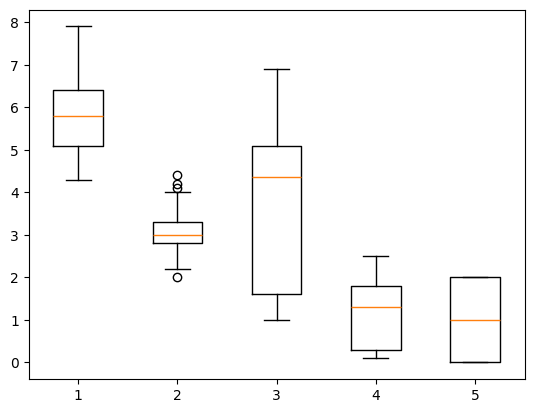

In [ ]:
import matplotlib.pyplot as plt
plt.boxplot(df)
plt.show()

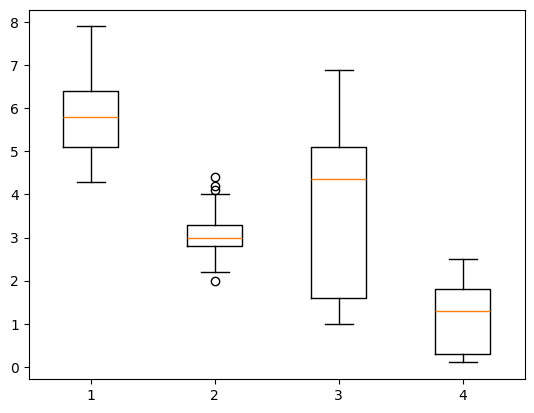

In [ ]:
import matplotlib.pyplot as plt
plt.boxplot(x)
plt.show()

In [ ]:

print(x.shape,y.shape)

(150, 4) (150,)


In [ ]:
from sklearn.preprocessing import  MinMaxScaler
sd=MinMaxScaler()
list=x.columns
x[list]=sd.fit_transform(x[list])

In [ ]:
x.head()

,a,b,c,d
0,0.222222,0.625000,0.067797,0.041667
1,0.166667,0.416667,0.067797,0.041667
2,0.111111,0.500000,0.050847,0.041667
3,0.083333,0.458333,0.084746,0.041667
4,0.194444,0.666667,0.067797,0.041667


Target
0    50
1    50
2    50
Name: count, dtype: int64


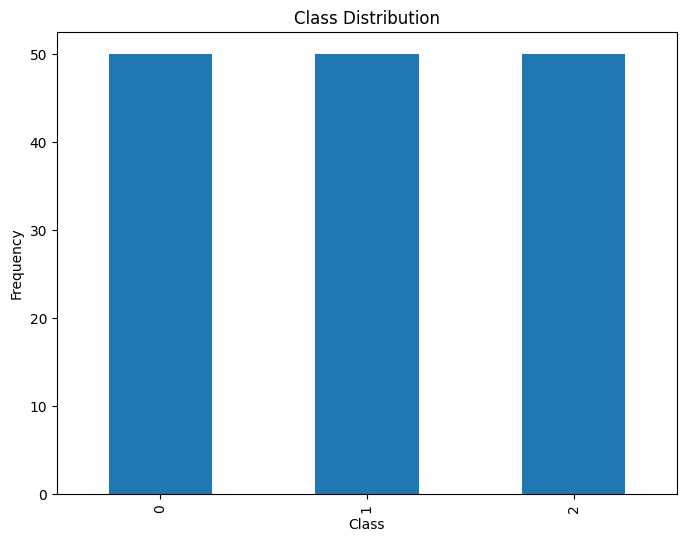

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame and 'target' is the column with class labels
class_counts = df['Target'].value_counts()

print(class_counts)

# Visualize with a bar plot
plt.figure(figsize=(8, 6))
class_counts.plot(kind='bar', title='Class Distribution')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.show()

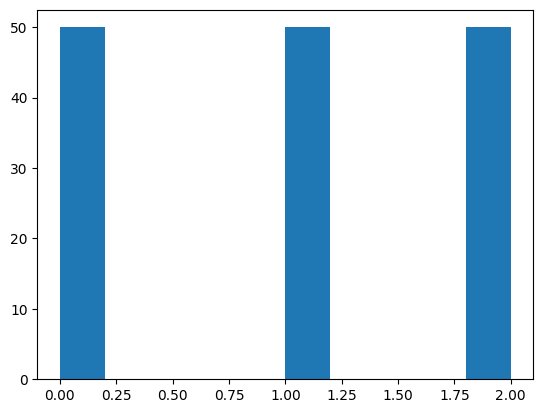

In [ ]:
plt.hist(y)
plt.show()

In [ ]:

from collections import Counter
c=Counter(y)
print(c)

Counter({0: 50, 1: 50, 2: 50})


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=.8,random_state=0)

In [ ]:
from sklearn import svm

model=svm.SVC()
model.fit(x_train,y_train)

y_predict= model.predict(x_test)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score

clf = LogisticRegression(max_iter=10000, random_state=0)
clf.fit(x_train, y_train)

acc = accuracy_score(y_test, clf.predict(x_test)) * 100
print(f"Logistic Regression model accuracy: {acc:.2f}%")

Logistic Regression model accuracy: 90.00%


In [ ]:
from sklearn.metrics import accuracy_score,precision_score,recall_score
acc=accuracy_score(y_test,y_predict)
prec=precision_score(y_test,y_predict,average = 'weighted')
rec=recall_score(y_test,y_predict,average = 'weighted')
print(acc,prec,rec)

1.0 1.0 1.0


# nn

In [ ]:
import numpy as np
import torch


In [ ]:
numpy_array_x=x.to_numpy()
numpy_array_y=y.to_numpy()
X=torch.from_numpy(numpy_array_x).type(torch.float32)
Y=torch.from_numpy(numpy_array_y).type(torch.float32)

In [ ]:
from torch import nn
torch.manual_seed(1)
model_0=nn.Sequential(nn.Linear(in_features=4,out_features=6),
                      nn.ReLU(),
                      nn.Linear(in_features=6,out_features=4),
                      nn.ReLU(),
                      nn.Linear(in_features=4,out_features=3))


In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,train_size=.80,random_state=1)

In [ ]:
X_train.dtype

torch.float32

In [ ]:
epochs=1000
nepoch=[]
train_loss_list=[]
test_loss_list=[]
loss_fun=nn.CrossEntropyLoss()
opt=torch.optim.AdamW(params=model_0.parameters(),lr=0.003)

In [ ]:
from torchmetrics import Accuracy, Precision, Recall, F1Score
for epoch in range(epochs):
  model_0.train()

  # Forward pass -> prediction
  train_logit=model_0(X_train) # Get logits

  #loss using  logits and target converted to long
  train_loss=loss_fun(train_logit,Y_train.long())
  train_loss_list.append(train_loss)

  opt.zero_grad()
  train_loss.backward()
  opt.step()


  model_0.eval()
  with torch.inference_mode():
    test_logit=model_0(X_test) # Get logits

    #loss using logits and target converted to long
    test_loss=loss_fun(test_logit,Y_test.long())
    test_loss_list.append(test_loss)
    nepoch.append(epoch)

  if epoch % 20 == 0:
    print(f"Epoch: {epoch}, Test Loss: {test_loss:.4f}, Train Loss: {train_loss:.4f}")


Epoch: 0, Test Loss: 1.1081, Train Loss: 1.1068
Epoch: 20, Test Loss: 1.1027, Train Loss: 1.0841
Epoch: 40, Test Loss: 1.0717, Train Loss: 1.0503
Epoch: 60, Test Loss: 0.9816, Train Loss: 0.9658
Epoch: 80, Test Loss: 0.8320, Train Loss: 0.8265
Epoch: 100, Test Loss: 0.6767, Train Loss: 0.6724
Epoch: 120, Test Loss: 0.5711, Train Loss: 0.5556
Epoch: 140, Test Loss: 0.4780, Train Loss: 0.4669
Epoch: 160, Test Loss: 0.3935, Train Loss: 0.3893
Epoch: 180, Test Loss: 0.3181, Train Loss: 0.3210
Epoch: 200, Test Loss: 0.2534, Train Loss: 0.2613
Epoch: 220, Test Loss: 0.2016, Train Loss: 0.2126
Epoch: 240, Test Loss: 0.1624, Train Loss: 0.1751
Epoch: 260, Test Loss: 0.1342, Train Loss: 0.1471
Epoch: 280, Test Loss: 0.1132, Train Loss: 0.1264
Epoch: 300, Test Loss: 0.0975, Train Loss: 0.1109
Epoch: 320, Test Loss: 0.0858, Train Loss: 0.0994
Epoch: 340, Test Loss: 0.0765, Train Loss: 0.0907
Epoch: 360, Test Loss: 0.0693, Train Loss: 0.0839
Epoch: 380, Test Loss: 0.0633, Train Loss: 0.0786
Epoch:

In [ ]:
'''

for epoch in range(epochs):
  #forward pass -> prediction

  model_0.train()

  train_logits=model_0(X_train) #logits
  train_predict=train_logits.softmax(dim=1).argmax(dim=1)

  train_loss=loss_fun(train_logits, Y_train.long())

  train_loss_list.append(train_loss)

  opt.zero_grad()

  train_loss.backward()

  opt.step()


  model_0.eval()
  with torch.inference_mode(): # Added parentheses for context manager

    test_logits=model_0(X_test) #logits
    test_predict=test_logits.softmax(dim=1).argmax(dim=1)
    test_loss=loss_fun(test_logits, Y_test.long())
    test_loss_list.append(test_loss)
    nepoch.append(epoch)


  if epoch % 100 == 0: # Changed to check for divisibility
    print(epoch ,test_loss, train_loss)

    '''

'\n\nfor epoch in range(epochs):\n  #forward pass -> prediction\n\n  model_0.train()\n\n  train_logits=model_0(X_train) #logits\n  train_predict=train_logits.softmax(dim=1).argmax(dim=1)\n\n  train_loss=loss_fun(train_logits, Y_train.long())\n\n  train_loss_list.append(train_loss)\n\n  opt.zero_grad()\n\n  train_loss.backward()\n\n  opt.step()\n\n\n  model_0.eval()\n  with torch.inference_mode(): # Added parentheses for context manager\n\n    test_logits=model_0(X_test) #logits\n    test_predict=test_logits.softmax(dim=1).argmax(dim=1)\n    test_loss=loss_fun(test_logits, Y_test.long())\n    test_loss_list.append(test_loss)\n    nepoch.append(epoch)\n\n\n  if epoch % 100 == 0: # Changed to check for divisibility\n    print(epoch ,test_loss, train_loss)\n\n    '

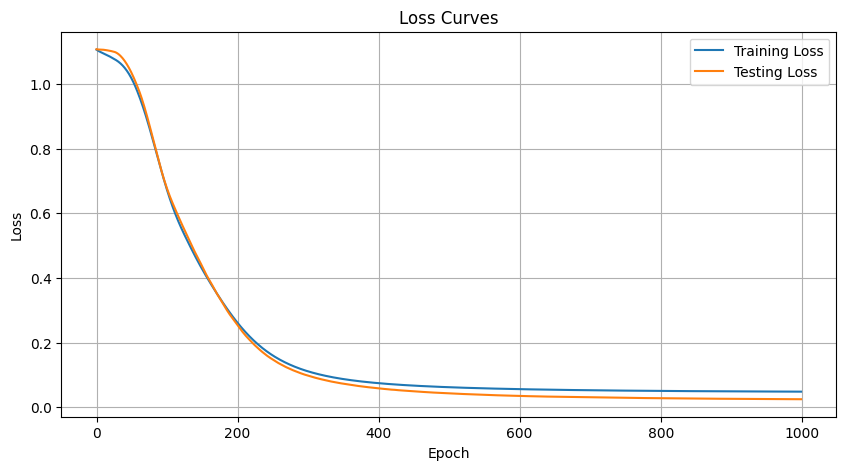

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(nepoch, np.array(torch.tensor(train_loss_list).numpy()), label='Training Loss')
plt.plot(nepoch, np.array(torch.tensor(test_loss_list).numpy()), label='Testing Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()
plt.grid(True)

In [ ]:
with torch.inference_mode():

    test_logit=model_0(X_test)
    pred=test_logit.softmax(dim=1).argmax(dim=1)

    print(pred[:5])

tensor([0, 1, 1, 0, 2])


In [ ]:

from torchmetrics import Accuracy, Precision, Recall, F1Score


In [ ]:
recall= Recall(task="multiclass", num_classes=3)
Acc=Accuracy(task="multiclass", num_classes=3)
precision= Precision(task="multiclass", num_classes=3)


recall.update(pred, Y_test.long())
Acc.update(pred, Y_test.long())
precision.update(pred, Y_test.long())

calculated_recall = recall.compute()
calculated_accuracy = Acc.compute()
calculated_precision = precision.compute()

print(f"Recall: {calculated_recall*100:.2f}%")
print(f"Accuracy: {calculated_accuracy*100:.2f}%")
print(f"Precision: {calculated_precision*100:.2f}%")

Recall: 100.00%
Accuracy: 100.00%
Precision: 100.00%
